In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
#Load Dataset
df=pd.read_csv("C:/Users/SANTOSH/Downloads/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.shape

(545, 13)

In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
#Check Missing Values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
#Fill Missing Values
df.fillna(df.mode().iloc[0], inplace=True)

In [11]:
#Check Duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
#Remove Duplicates
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(545, 13)

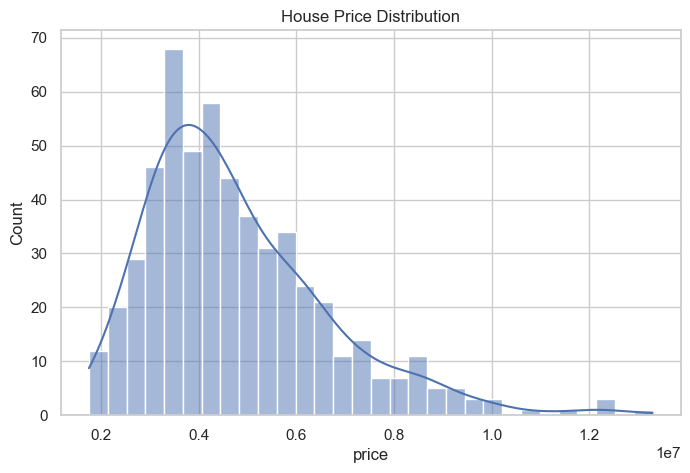

In [14]:
#House Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("House Price Distribution")

plt.show()

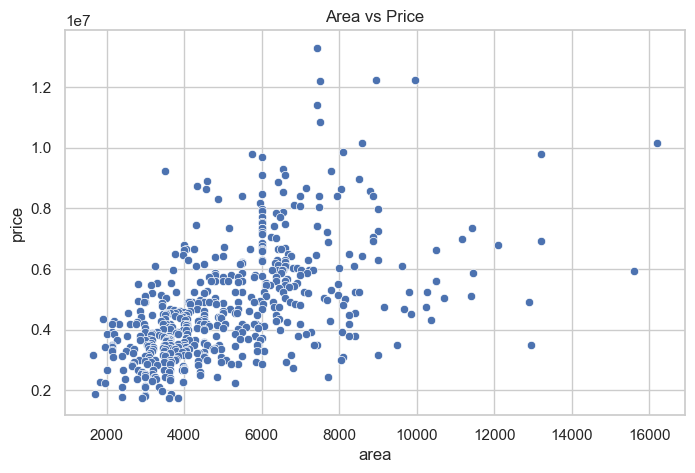

In [15]:
#Area vs Price
plt.figure(figsize=(8,5))

sns.scatterplot(x="area", y="price", data=df)

plt.title("Area vs Price")

plt.show()

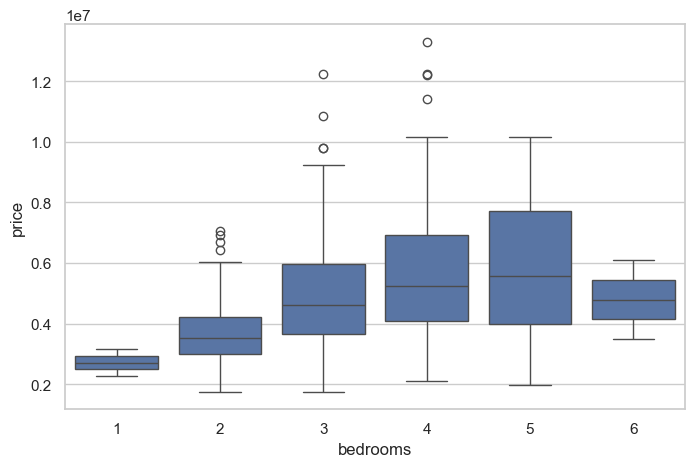

In [16]:
#Bedrooms vs Price
plt.figure(figsize=(8,5))

sns.boxplot(x="bedrooms", y="price", data=df)

plt.show()

In [17]:
data = df.copy()

In [18]:
#Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = encoder.fit_transform(data[col])

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


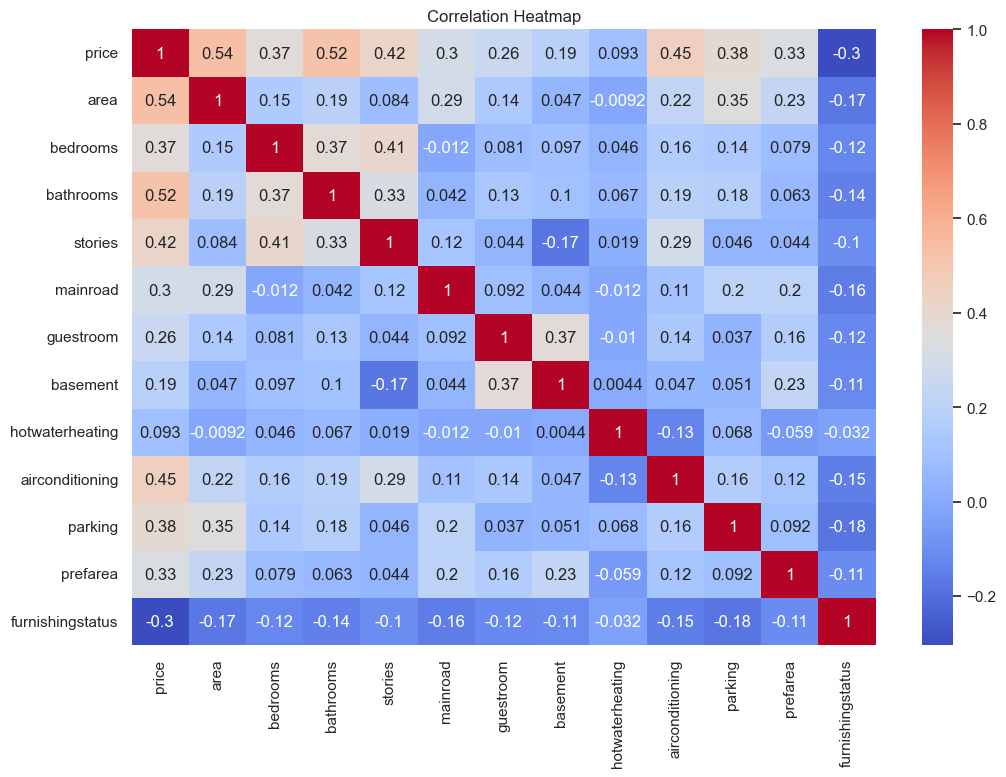

In [19]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [20]:
#Check Features
X = data.drop("price", axis=1)

y = data["price"]
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0


In [21]:
#Split Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
#Check Training Shape
print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


In [26]:
#Import Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [27]:
#Train Linear Regression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
#Train Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [29]:
#Train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
#Predict Using All Models
lr_pred = lr_model.predict(X_test)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

In [31]:
#Import Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [32]:
#Evaluate All Models
models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():

    print("="*40)

    print(name)

    print("MAE :", mean_absolute_error(y_test, pred))

    print("MSE :", mean_squared_error(y_test, pred))

    print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

    print("R2 Score :", r2_score(y_test, pred))

Linear Regression
MAE : 979679.6912959903
MSE : 1771751116594.0347
RMSE : 1331071.4167895105
R2 Score : 0.6494754192267804
Decision Tree
MAE : 1222399.0825688073
MSE : 2688177649082.569
RMSE : 1639566.2990811225
R2 Score : 0.4681689010023007
Random Forest
MAE : 1025289.6821100918
MSE : 1963538216518.6526
RMSE : 1401263.0789821919
R2 Score : 0.6115321143409216


In [33]:
#Compare Models
comparison = {
    "Model": [],
    "MAE": [],
    "RMSE": [],
    "R2 Score": []
}

for name, pred in models.items():

    comparison["Model"].append(name)

    comparison["MAE"].append(mean_absolute_error(y_test, pred))

    comparison["RMSE"].append(np.sqrt(mean_squared_error(y_test, pred)))

    comparison["R2 Score"].append(r2_score(y_test, pred))

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.796797e+05,1.331071e+06,0.649475
1,Decision Tree,1.222399e+06,1.639566e+06,0.468169
2,Random Forest,1.025290e+06,1.401263e+06,0.611532


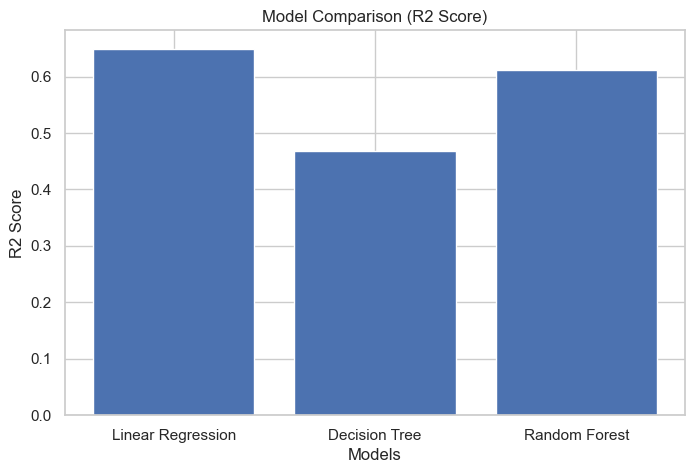

In [34]:
#Comparison Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"], comparison_df["R2 Score"])

plt.title("Model Comparison (R2 Score)")

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.show()

In [35]:
#Best Model
best_model = comparison_df.loc[
    comparison_df["R2 Score"].idxmax()
]

print(best_model)

Model       Linear Regression
MAE             979679.691296
RMSE            1331071.41679
R2 Score             0.649475
Name: 0, dtype: object
